In [17]:
import random 
import time
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
from torch.distributions import Categorical
from torch.optim.lr_scheduler import LinearLR

In [18]:
env_id = "CartPole-v1"


num_envs = 16
n_steps = 5
total_timesteps = 500000

critic_learning_rate = 0.001
actor_learning_rate = 0.0003
gamma = 0.995
video_path = "A2C_lunar_videos"
seed = None
batch_size = num_envs * n_steps
total_updates = total_timesteps // batch_size # 500,000 // 80 = 6,250
num_iterations = total_updates * (batch_size // num_envs) # 6,250 * 5 = 31,250 loop iterations

In [19]:
def make_env(env_id, capture_video, seed=None):
    if capture_video:
        env = gym.make(env_id, render_mode="rgb_array")
        # Episode trigger needed so it records every episode
        env = gym.wrappers.RecordVideo(env, video_path, episode_trigger=lambda episode: True)
    else:
        env = gym.make(env_id)
        
    env = gym.wrappers.RecordEpisodeStatistics(env)
    
    if seed is not None:
        env.action_space.seed(seed)
    return env

In [20]:
# make environments
env = gym.vector.AsyncVectorEnv([
    lambda: make_env(
        env_id,
        capture_video=False,
        seed=seed if seed is None else seed + i) 
    for i in range (num_envs)
])

In [21]:
class ActorNetwork(nn.Module):
    def __init__(self, env, hidden=128):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(env.single_observation_space.shape[0], hidden),
            nn.ReLU(),
            nn.Linear(hidden, env.single_action_space.n)
        )

    def forward(self, x):
        return self.network(x)
    
class CriticNetwork(nn.Module):
    def __init__(self, env, hidden=128):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(env.single_observation_space.shape[0], hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, x):
        return self.network(x)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [23]:
Actor = ActorNetwork(env).to(device)
Critic = CriticNetwork(env).to(device)

In [24]:
actor_optim = torch.optim.Adam(Actor.parameters(), lr=actor_learning_rate)
critic_optim = torch.optim.Adam(Critic.parameters(), lr=critic_learning_rate)
actor_scheduler = LinearLR(actor_optim, start_factor=1.0, end_factor=0.0, total_iters=total_updates)
critic_scheduler = LinearLR(critic_optim, start_factor=1.0, end_factor=0.0, total_iters=total_updates)

In [25]:
def np2torch(a):
    return torch.tensor(a).float().to(device)

In [26]:
n_envs = env.num_envs
log_probs = []
episode_rewards = np.zeros(n_envs)
episode_returns = []
episode_count = 0
alpha = 0.01
entropy = []

advantage = []
td_targets = []
preds = []

obs, _ = env.reset()

for global_step in range(num_iterations):
    logits = Actor(np2torch(obs))
    m = Categorical(logits=logits)
    action = m.sample()
    entropy.append(m.entropy())
    log_probs.append(m.log_prob(action))
    actions_np = action.cpu().numpy()

    next_obs, reward, terminated, truncated, infos = env.step(actions_np)
    dones = np.logical_or(terminated, truncated)
    episode_rewards += reward


    tensor_next_obs = np2torch(np.array(next_obs))
    tensor_reward = np2torch(np.array(reward)).view(-1, 1)
    tensor_obs = np2torch(np.array(obs))
    tensor_actions = torch.tensor(action, dtype=torch.int64, device=device)
    tensor_dones = torch.tensor(dones, dtype=torch.float32, device=device).view(-1, 1)
    tensor_terminated = torch.tensor(terminated, dtype=torch.float32, device=device).view(-1, 1)

    if "final_observation" in infos:
        for idx, final_obs in enumerate(infos["final_observation"]):
            if final_obs is not None:
                tensor_next_obs[idx] = np2torch(final_obs)

    with torch.no_grad():
        v_next = Critic(tensor_next_obs)
        td_target = tensor_reward + gamma*(1-tensor_terminated)*v_next

    pred = Critic(tensor_obs)
    preds.append(pred)
    td_targets.append(td_target)
    advantage.append(td_target - pred)

    for i in range(num_envs):
        if dones[i]:
            ret = episode_rewards[i]
            episode_returns.append(ret)
            episode_count += 1
            print(f"global_step={global_step + i}, episode={episode_count}, episode_return={ret}")
            episode_rewards[i] = 0


    if len(log_probs) * num_envs >= batch_size:
        t_advantage = torch.stack(advantage).detach().view(-1).to(device)
        # Advantage normalisation
        t_advantage = (t_advantage - t_advantage.mean()) / (t_advantage.std() + 1e-8)
        t_targets = torch.stack(td_targets).detach().view(-1).to(device)
        t_log_probs = torch.stack(log_probs).view(-1).to(device)
        t_preds = torch.stack(preds).view(-1).to(device)

        critic_loss = torch.nn.functional.mse_loss(t_targets, t_preds).mean()
        mean_entropy = torch.stack(entropy).mean()
        actor_loss = -(t_log_probs * t_advantage).mean()
        actor_loss = actor_loss - (alpha * mean_entropy)

        log_probs = []
        advantage = []
        td_targets = []
        preds = []
        entropy = []

        actor_optim.zero_grad()
        actor_loss.backward()
        actor_optim.step()

        critic_optim.zero_grad()
        critic_loss.backward()
        critic_optim.step()

        actor_scheduler.step()
        critic_scheduler.step()
    
    obs = next_obs

    if len(episode_returns) > 10 and np.all(np.equal(episode_returns[-10:], 500)):
        print("max reward achieved")
        break

C:\Users\soseb\AppData\Local\Temp\ipykernel_18352\3855845887.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tensor_actions = torch.tensor(action, dtype=torch.int64, device=device)


global_step=13, episode=1, episode_return=9.0
global_step=19, episode=2, episode_return=12.0
global_step=25, episode=3, episode_return=12.0
global_step=23, episode=4, episode_return=14.0
global_step=26, episode=5, episode_return=14.0
global_step=28, episode=6, episode_return=14.0
global_step=14, episode=7, episode_return=15.0
global_step=26, episode=8, episode_return=15.0
global_step=16, episode=9, episode_return=16.0
global_step=22, episode=10, episode_return=16.0
global_step=24, episode=11, episode_return=16.0
global_step=31, episode=12, episode_return=21.0
global_step=25, episode=13, episode_return=22.0
global_step=33, episode=14, episode_return=9.0
global_step=27, episode=15, episode_return=26.0
global_step=32, episode=16, episode_return=9.0
global_step=32, episode=17, episode_return=27.0
global_step=36, episode=18, episode_return=16.0
global_step=43, episode=19, episode_return=17.0
global_step=35, episode=20, episode_return=33.0
global_step=44, episode=21, episode_return=19.0
glob

In [27]:
env.close()

In [28]:
def smooth(x, a=0.1):
    y = [x[0]]
    for xi in x[1:]:
        yi = a * xi + (1-a) * y[-1]
        y.append(yi)
    return y

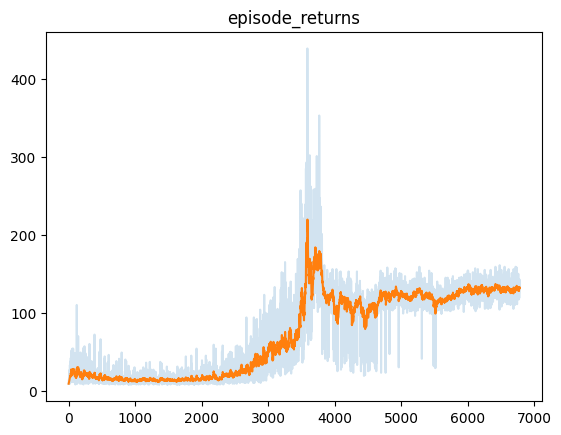

In [29]:
plt.plot(episode_returns, alpha=0.2)
plt.plot(smooth(episode_returns))
plt.title("episode_returns")
plt.show()

In [30]:
model_path = "A2C_network.pth"
torch.save(Actor.state_dict(), model_path)

In [31]:
envs_eval = gym.vector.SyncVectorEnv([lambda: make_env(env_id, True)])
eval_model = ActorNetwork(envs_eval).to(device)
eval_model.load_state_dict(torch.load(model_path, map_location=device))
eval_model.eval()

ActorNetwork(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [32]:
n_episodes_eval = 10
eval_returns = np.zeros(n_episodes_eval)

for i in range(n_episodes_eval):
    obs, _ = envs_eval.reset()
    episode_reward_sum = 0.0  
    episode_done = False
    
    while not episode_done:
        # 1. obs is already batched by the vectorized env, so just convert to tensor
        obs_tensor = np2torch(obs).to(device)
        
        with torch.no_grad():
            logits = eval_model(obs_tensor)
            
            # 2. Get the best action, but KEEP it as a tensor (don't use .item())
            action = torch.argmax(logits, dim=-1)

        # 3. Convert the tensor to a numpy array (e.g., [2]) so the vector env can iterate over it
        action_np = action.cpu().numpy()

        next_obs, reward, terminated, truncated, infos = envs_eval.step(action_np)
        
        # 4. Because it's a vector env, reward, terminated, and truncated are ARRAYS. 
        # We grab the 0th index assuming your eval vector has 1 environment inside it.
        episode_reward_sum += reward[0]
        obs = next_obs
        
        if terminated[0] or truncated[0]:
            eval_returns[i] = episode_reward_sum
            print(f"Episode: {i + 1}/{n_episodes_eval}, Return: {episode_reward_sum}")
            episode_done = True

envs_eval.close()

print("-" * 30)
print(f"Average Evaluation Return: {np.mean(eval_returns):.2f} +/- {np.std(eval_returns):.2f}")

Episode: 1/10, Return: 132.0
Episode: 2/10, Return: 127.0
Episode: 3/10, Return: 142.0
Episode: 4/10, Return: 132.0
Episode: 5/10, Return: 128.0
Episode: 6/10, Return: 139.0
Episode: 7/10, Return: 127.0
Episode: 8/10, Return: 138.0
Episode: 9/10, Return: 125.0
Episode: 10/10, Return: 137.0
------------------------------
Average Evaluation Return: 132.70 +/- 5.66
